# 리포트 8-1 — 마이크로도플러: 무엇을 보고 있나

> **8 권은 다섯 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) · [08_5 바이스태틱](08_5_bistatic.ipynb)

> **호버링하는 드론은 제자리에 있지만 프로펠러는 돈다.** 그 회전만이 되돌아오는 신호를 흔든다 — 이 편은 그 장면을 먼저 세운다.

이 편은 **시나리오와 측정 모형**만 다룬다. 계산 엔진의 비교는 8-2, 무늬를 정하는 요인들은 8-3, 표본화 한계는 8-4 다.

⭐ 숫자는 전부 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다.


## 표적이 실제로 무엇을 하고 있나

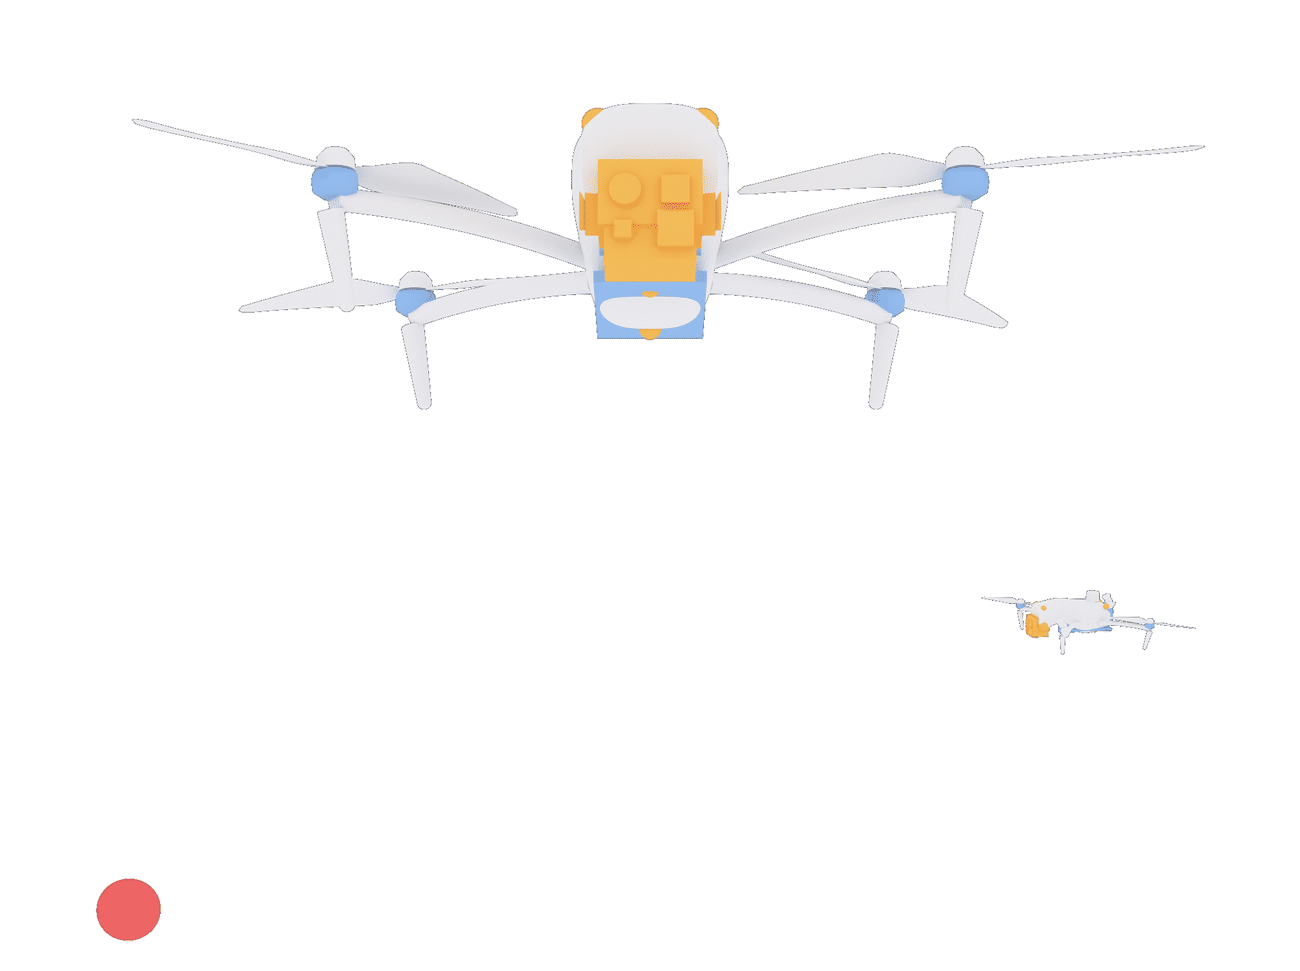

호버링하는 DJI Matrice 4E. **아래칸이 배치**다 — 붉은 공 하나가 레이더이고, 거기서 3 m 떨어진 곳에 드론이 떠 있다(방위 0° · 앙각 -15°, 즉 레이더가 드론을 올려다본다). 공이 하나인 이유는 기선이 0 인 **진짜 모노스태틱**이라 송신기와 수신기가 같은 점에 있기 때문이다. **위칸**은 그 레이더 시선에서 표적을 당겨 본 모습이다.

⭐볼 것은 하나다 — **동체는 한 픽셀도 안 움직이는데 프로펠러 넷의 날 방향만 프레임마다 바뀐다**(호버 3800 rpm, 로터마다 조금씩 다르고 CW/CCW 가 섞여 있다). 그 바뀌는 부분이 되돌아오는 신호의 위상을 흔들고, 그것이 이 편들이 다루는 마이크로도플러다.

⚠ 실제 날은 초당 63 바퀴를 돌아 눈으로는 볼 수 없다 — 이 애니메이션은 프레임 사이 실시간 0.66 ms 를 30 ms 로 늘여 튼 **약 46 배 슬로모션**이다(프레임당 15° 회전, 96 프레임 = 블레이드 8 주기). ⚠ 로터 간 누적 어긋남이 3.2° 뿐이라 **산포는 여기 안 보인다** — 그 성질은 8-3 이 담당한다.


## 배치 — 무엇이 어디에 있나

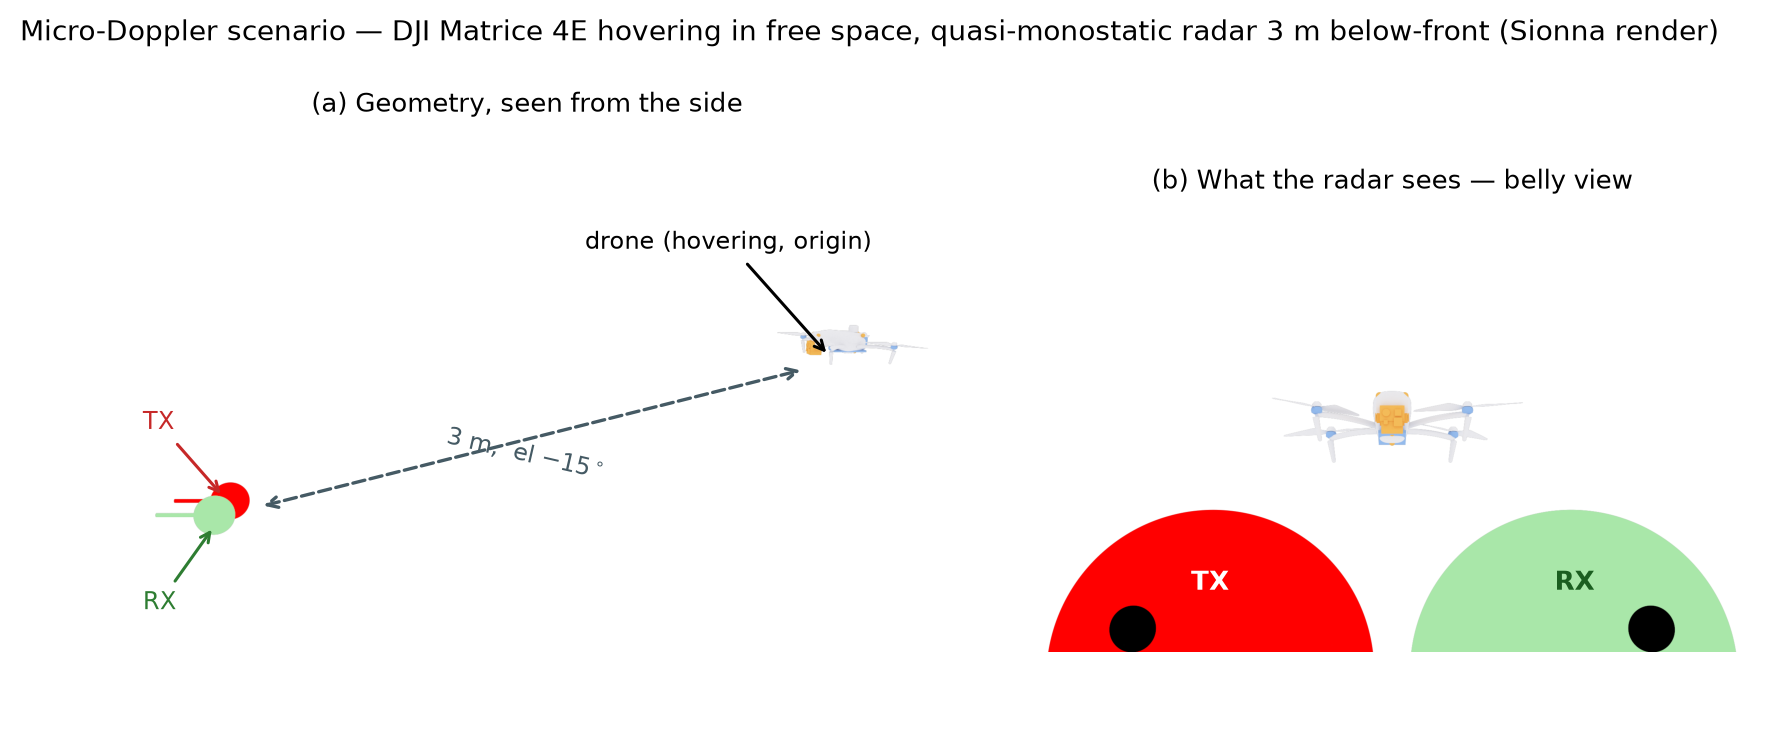

**공통**: DJI Matrice 4E 한 대가 **제자리 호버링**한다(이동 0, 벌크 도플러 0). 환경은 자유공간이다 — 지면도 벽도 클러터도 잡음도 두지 않았다. 레이더는 기체의 **배 쪽 아래**에서 본다(방위 0°, 앙각 −15°). 지상 레이더가 나는 드론을 보는 각도다.

| | |
|---|---|
| 기체 | DJI Matrice 4E |
| 자세 | 방위 0° · 앙각 -15° (배 쪽) |
| 반송파 | 3.50 GHz (5G n78 대역의 반송파만 빌렸다) |
| 호버 회전수 | 3800 rpm |
| 날개끝 도플러 | 1230 Hz |
| 블레이드 통과율 | 126.7 Hz (= 플래시 7.9 ms 마다) |
| 원거리장 경계 | 2D²/λ = 8.3 m |

⭐ **측정 모형 — 파형이 아니다.** 이 편들의 신호는 h(t) = Σ a_p·exp(−j2πf_c·τ_p) 로, **3.50 GHz 단일 톤(CW)** 의 채널 응답이다. 5G 파형을 변조해 쏜 것이 아니라 반송파 주파수만 n78 에서 빌렸다. PRF 는 «채널을 얼마나 자주 재느냐»(슬로타임 표본율)이지 펄스 반복률이 아니다. 실제 5G 파형을 태우면 어떻게 되는지는 **8-4** 가 잰다.

⚠ **없는 것을 적어 둔다** — 잡음 0 · 클러터 0 · 지면 0 · 다중경로 0. 즉 이 편들의 수치는 **상한**이고, 현실 성능이 아니다.


## 경로 렌더 — Sionna 가 실제로 찾은 것

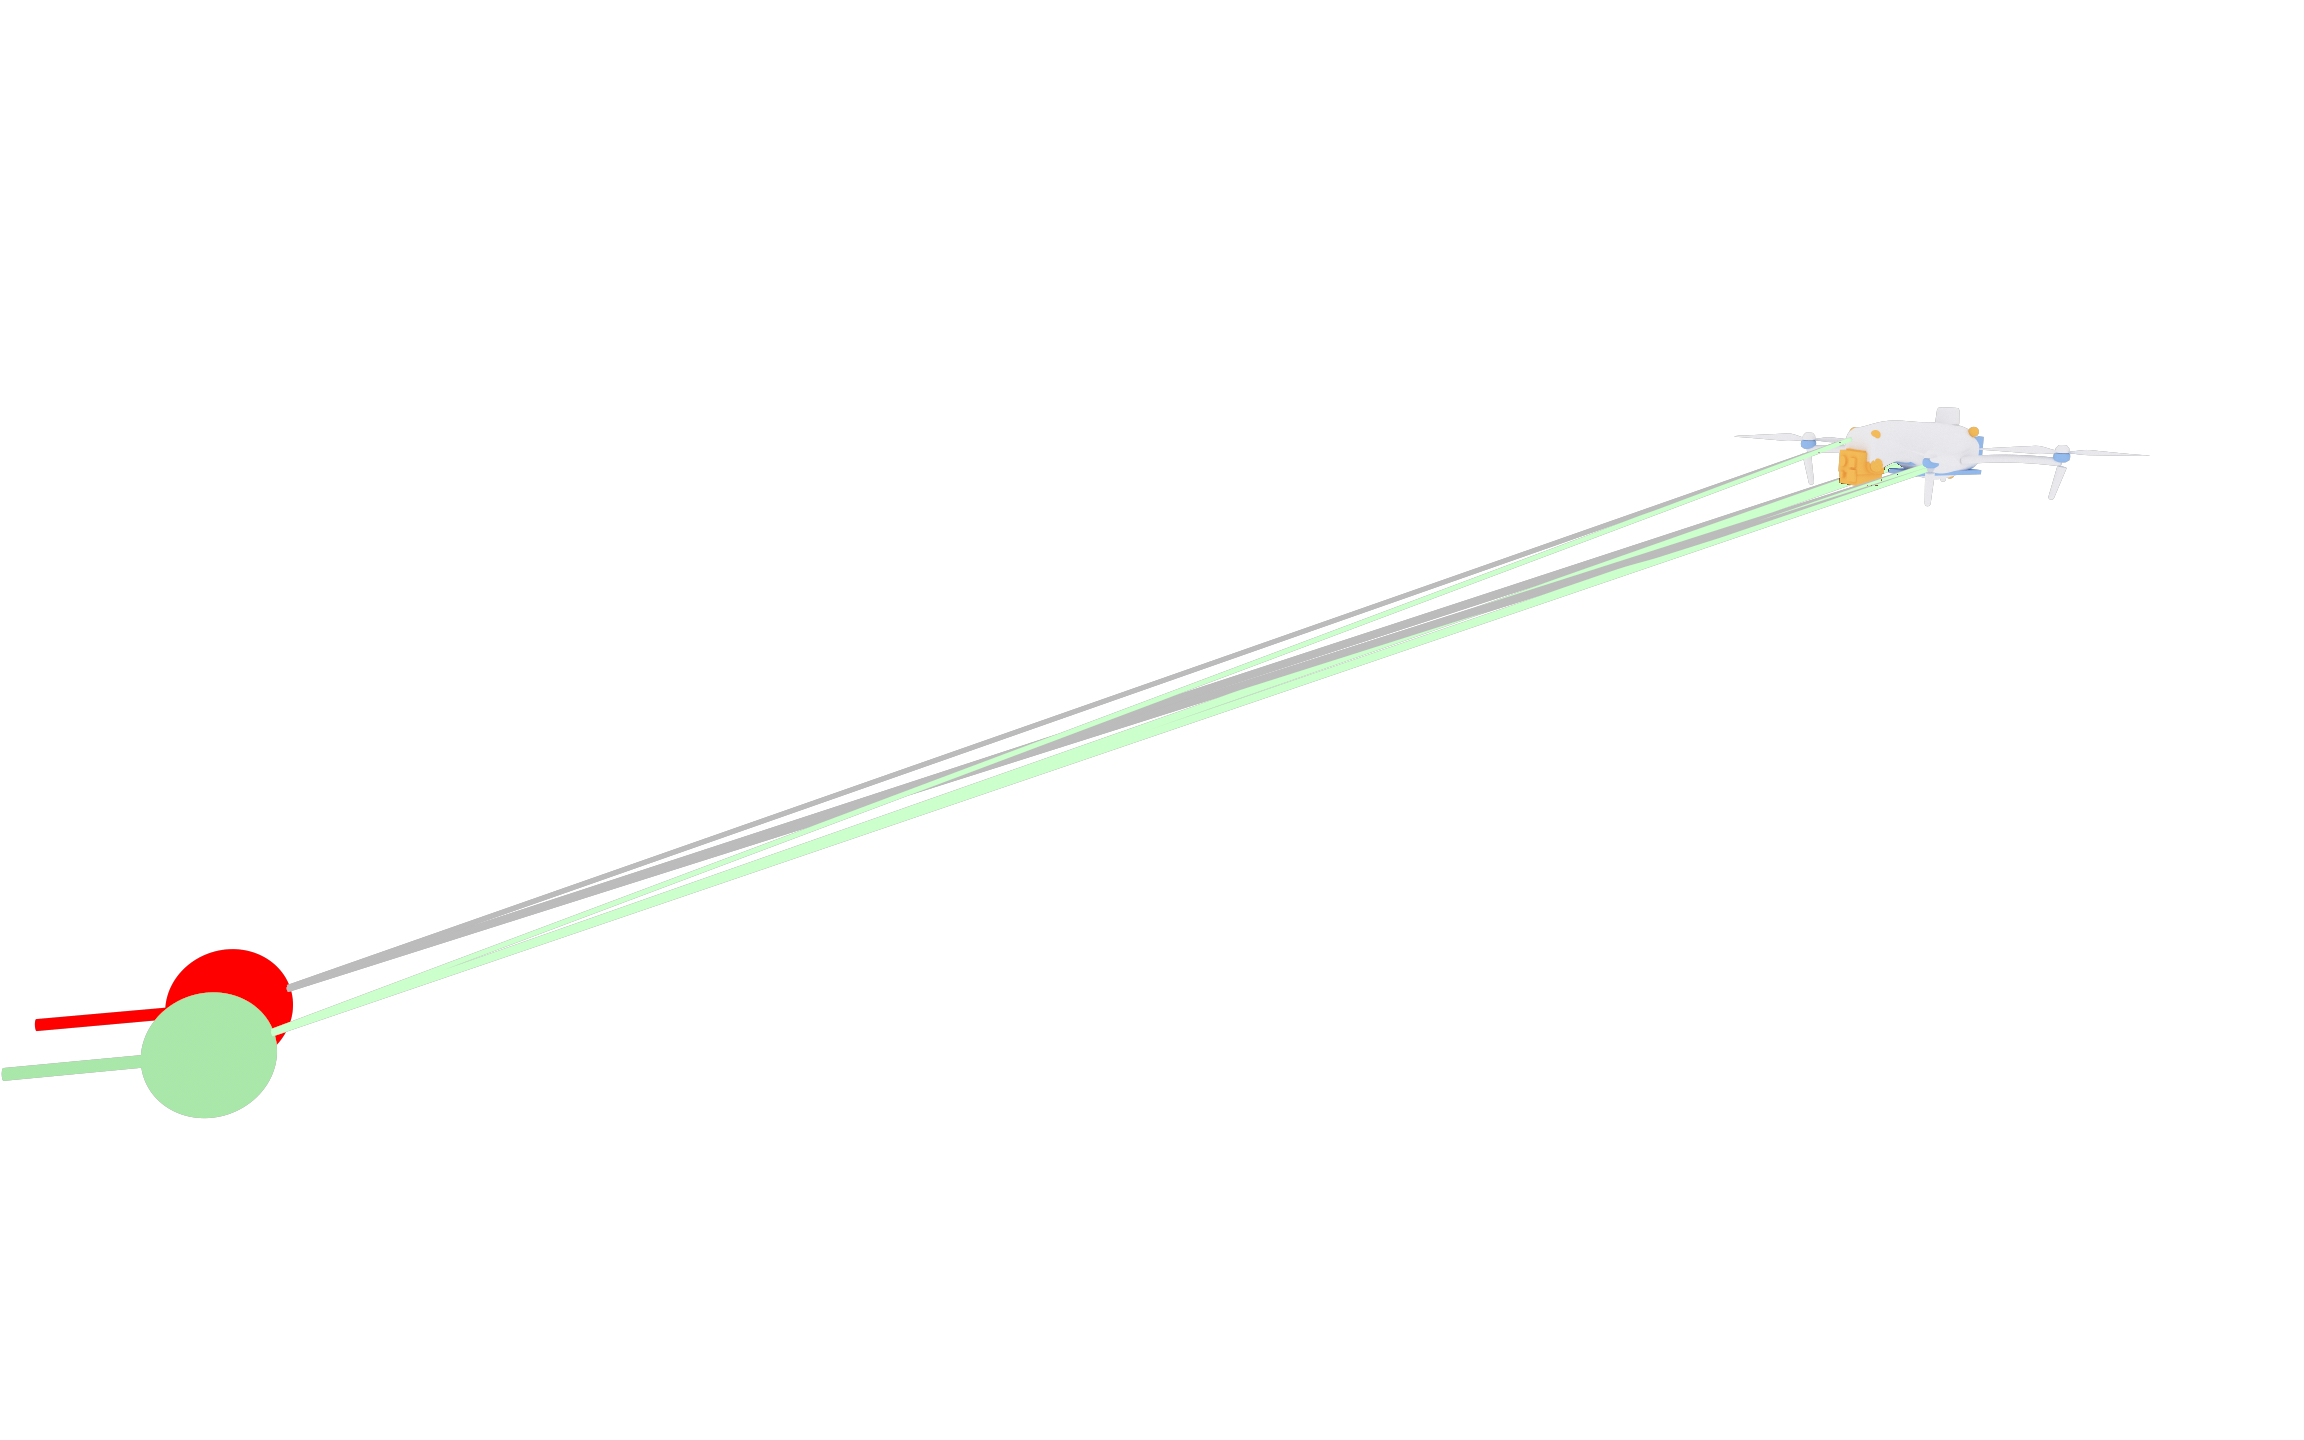

**PathSolver 가 실제로 찾은 경로 10개**(TX→RX 직행 1 + 표적 경유 **9개**)가 씬 위에 겹쳐 그려져 있다. 8-2 의 맵에서 Sionna 무늬가 성긴 이유가 이 그림에 있다 — 경로 열 개 남짓이 그 엔진의 재료 전부다.

⭐ 여기서 «경로» 는 광선이 표적을 맞고 돌아온 **한 가닥**이다. 우리 SBR+PO 는 표적 표면을 λ/12 격자로 덮어 **수십만 점**을 적분하므로 재료의 밀도가 다르다 — 그 차이가 무엇을 만드는지가 8-2 의 주제다.


## 이 편이 서 있는 자리

| 다음 | 무엇을 답하나 |
|---|---|
| [08_2 세 엔진과 거리](08_2_engines.ipynb) | 같은 장면을 세 가지로 계산하면 무엇이 갈리나 |
| [08_3 무늬를 정하는 것](08_3_pattern.ipynb) | 회전수·가림·산포가 무늬를 어떻게 바꾸나 |
| [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) | 광선 비용과 조명원 반복률의 한계 |

⚠ 이 편은 **모노스태틱**이다. 바이스태틱 기하로 가면 무엇이 달라지는지는 [08_5 바이스태틱](08_5_bistatic.ipynb) 이 다룬다 — 단 그 편도 **기하만** 다루고 기준·감시 2채널 처리(ECA·CAF)는 아직 쓰지 않는다.
